In [1]:
from Bagging_for_LID.Plotting.Plots.distance_CDF import *
from Bagging_for_LID.run_files.distance_LID_running import *

In [2]:
from pathlib import Path
import os
import sys

In [3]:
PROJECT_ROOT = Path.cwd().resolve().parent
save_dir = PROJECT_ROOT / "Output"
save_dir.mkdir(parents=True, exist_ok=True)

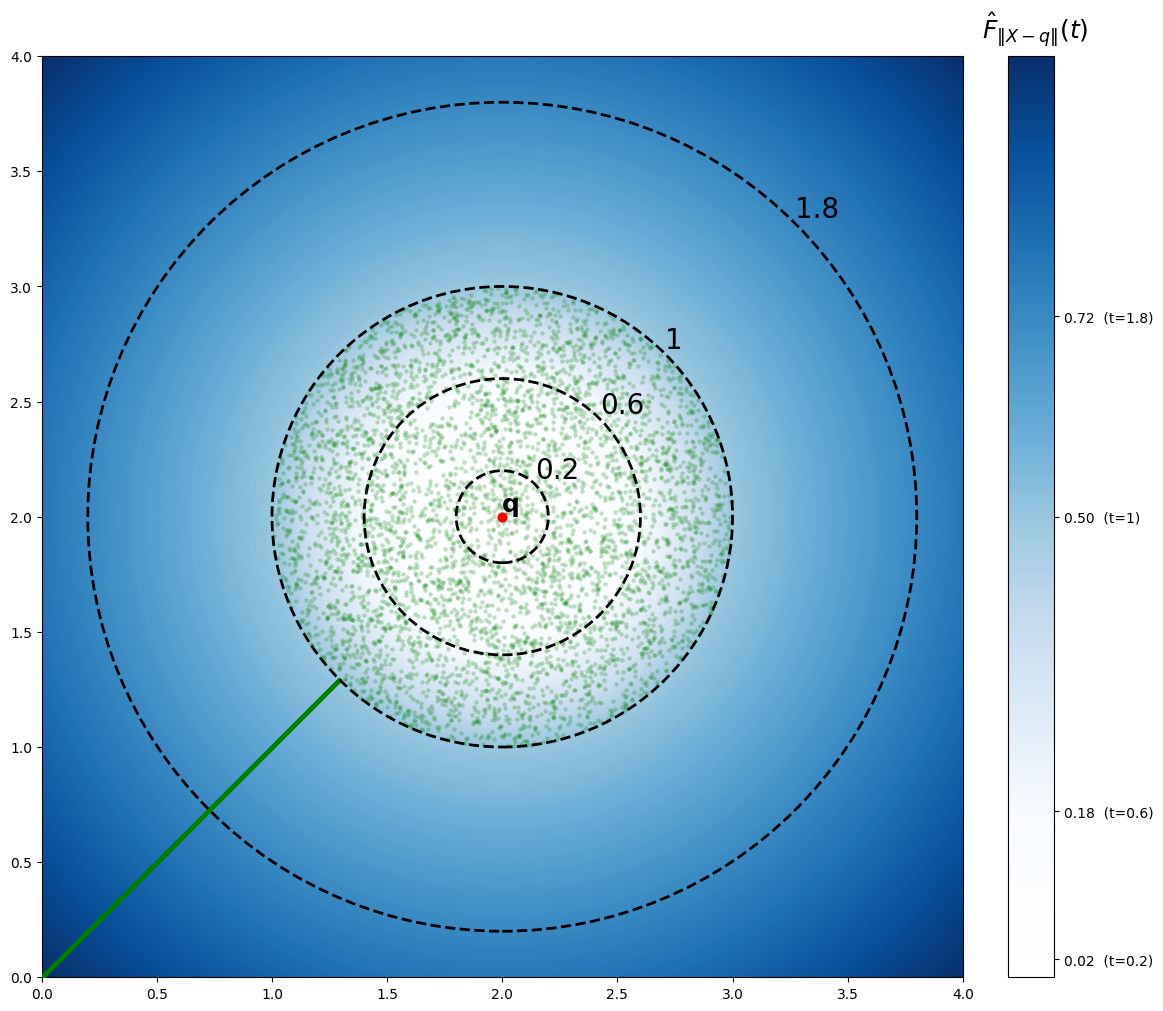

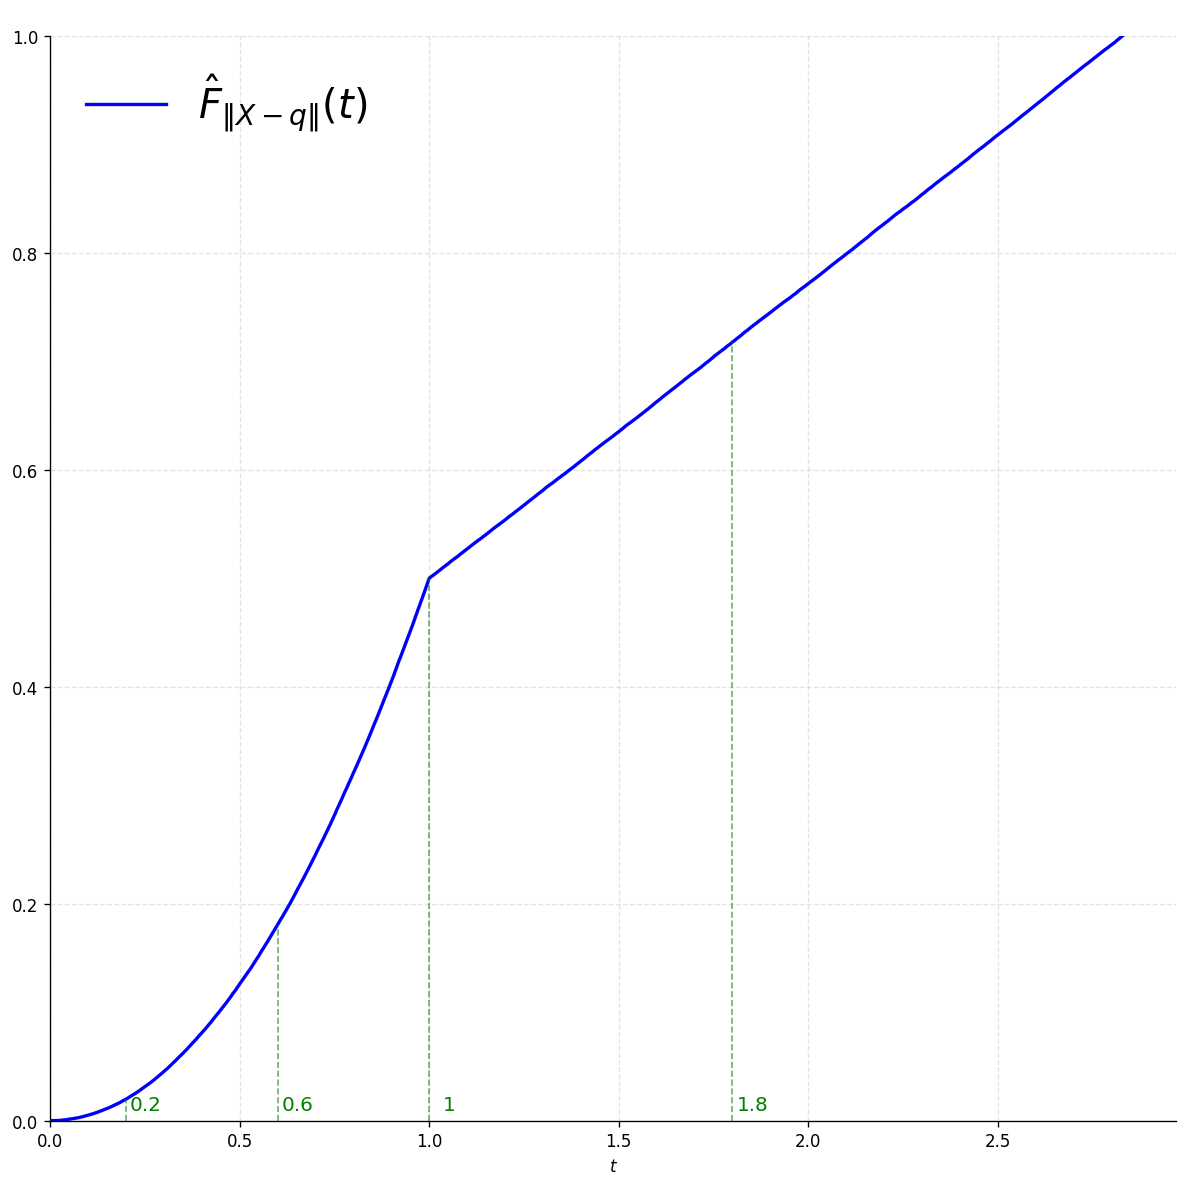

In [4]:
# 1) Generate data
bs = 200000
X, intrinsic_dims = lollipop_dataset(bs, seed=0, categorical=0.5)

# 2) Fix query point
q = (2, 2)
qx, qy = q

# 3) Choose view box 
extent = (0,4,0,4)

# 4) Choose which probabilities to mark
#quantile_probs = (0.2, 0.6, 1)

# 5) Compute circle radii from the samples (both plots use identical circles)
#circle_ts = distance_quantiles_from_samples(X, q=q, probs=quantile_probs)
circle_ts = (0.2, 0.6, 1, 1.8)

# 6) Subsample points for overlay (optional)
rng = np.random.default_rng(0)
P_plot = X[rng.choice(X.shape[0], size=10000, replace=False)]

# ---- 2D field plot ----
F = empirical_CDF(X, q=q)

fig1, ax1, im1 = plot_distance_cdf_field(
    F,
    q=q,
    extent=extent,
    circle_ts=circle_ts,
    sample_points=P_plot,
    figsize=(19, 10),
    sample_kwargs=dict(s=10, c="green", alpha=0.25, linewidths=0),
    quantile_probs=None,
    grid_res=700,
    cmap_name='Blues',
    save_name='lollipop_cdf_example_heatmap.png',
    colorbar_label=r"$\hat{F}_{\|X-q\|}(t)$",
    save_path=save_dir
)

# ---- CDF curve plot ----
fig2, ax2, ts_used, ps_used = plot_distance_cdf_curve(
    samples=X,
    q=q,
    circle_ts=circle_ts,
    figsize=(10, 10),
    title=" ",
    save_name='lollipop_cdf_example_curve.png',
    marker_fontsize=12,
    save_path=save_dir
)

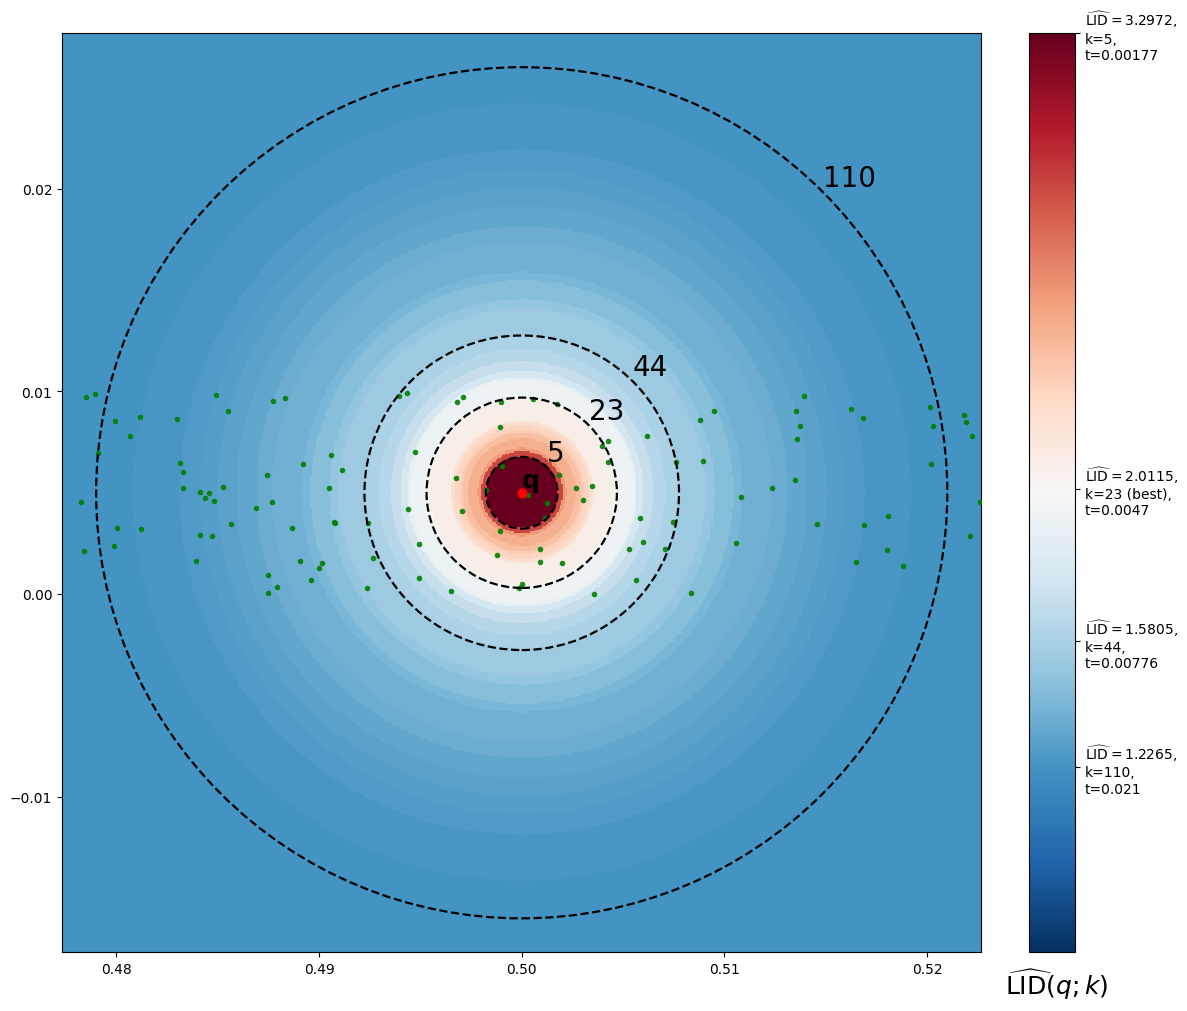

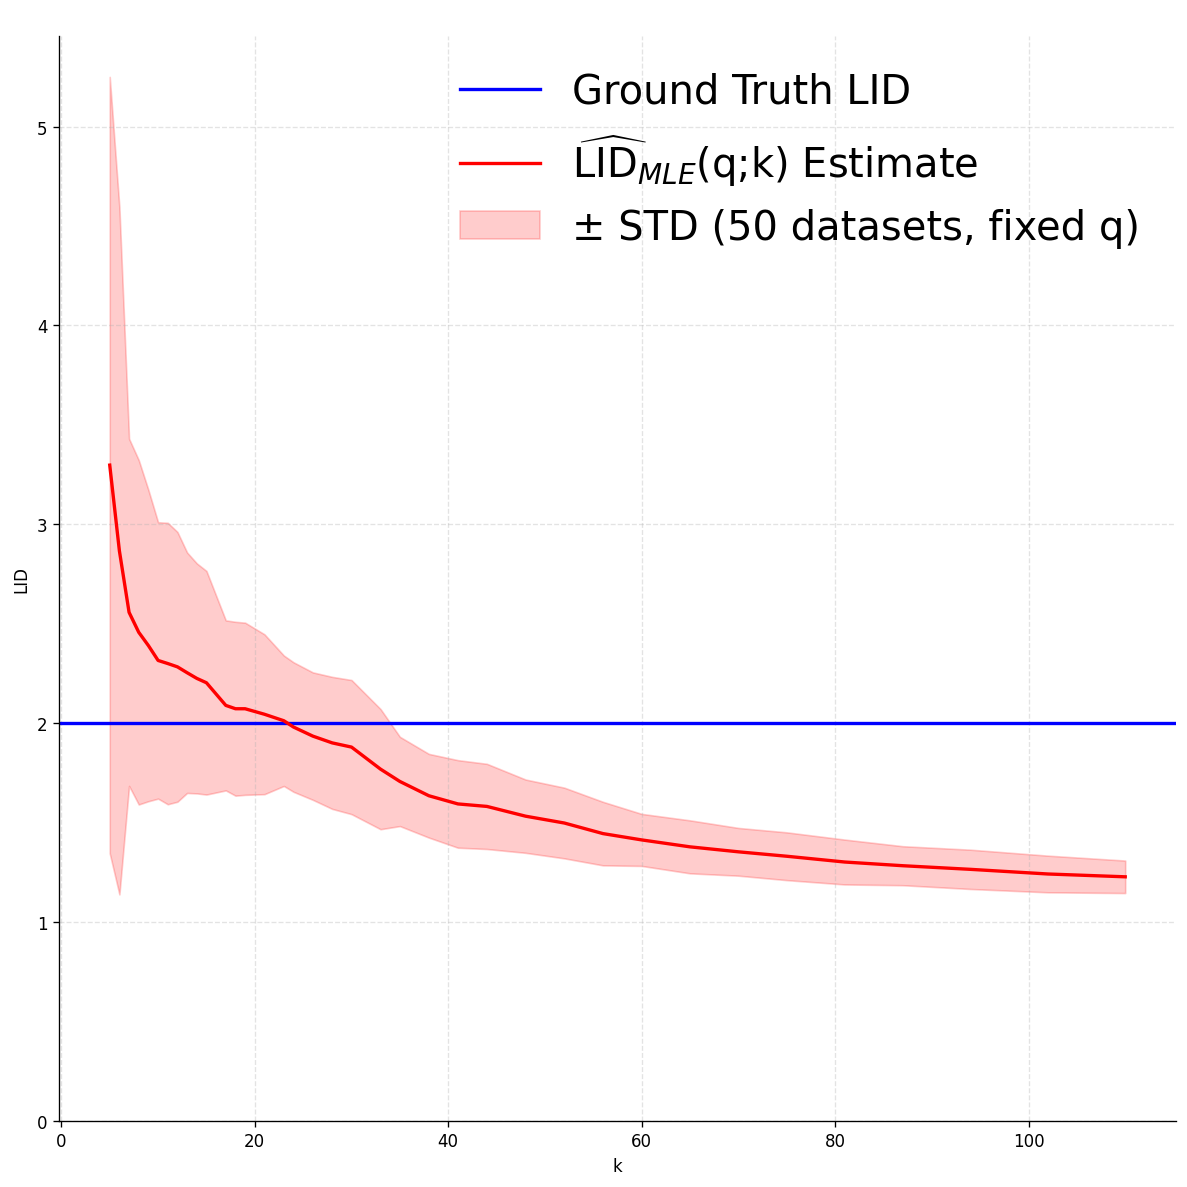

In [6]:
#Setup experiment
load=False #Load already complete experiment .pkl files.
directory=r'C:\pkls\ribbon_test_example' #Directory for saving and loading
save_name='ribbon_test_example' #Save and load .pkl files with this name prefix.
multiprocess=True #Toggle multiprocessing

#Setup ranges
n = 2500
krange = geom_prog(min=5, max=200, step=50, integer=True, remove_duplicates=True)
trange = [t for t in range(50)]
query = [np.array([[0.5, 0.005]]), np.array([2]), None, np.array([2])]

#Generate experiment results
experiments = generate_all_experiments(n=n, krange=krange, trange=trange, query=query, load=load, directory=directory, save_name=save_name, multiprocess=multiprocess)
exps, experiments_0_k_with_avg_estimates, experiments_t_k = avg_experiments_using_t_as_index(experiments, trange, k_geomprog_large)
exps_trimmed = [experiments_0_k_with_avg_estimates[k] for k in k_geomprog_large[0:len(k_geomprog_large)-8]]

#LID heatmap plot
fig, ax, im, (ks, radii, vals, gt, best_k) = plot_lid_field(
    exps_trimmed,
    i=n,
    figsize=(18, 10),
    points_kwargs=dict(s=16, c="green", alpha=0.9, linewidths=0),
    cmap_name="RdBu_r",
    save_name="ribbon_LID_example_heatmap.png",
    title = ' ',
    save_path=save_dir
)

#LID curve plot
figC, axC = plot_lid_curve(
    exps_trimmed,
    n,
    figsize=(10, 10),
    param="k",
    title=" ",
    save_name='ribbon_LID_example_curve.png',
    n_estimates=len(trange),
    save_path=save_dir
)